# Results of sc RNA

In [3]:
from deeptan.graph.model import DeepTAN
from deeptan.utils.uni import get_map_location

## Read feature names

In [4]:
import os

In [5]:
model_path="/mnt/hdd2/homext/wuch/xn2p/run/logs/GSE226097_Annotated_split_strata/seed_42/DeepTAN_20250318162452_U0Jku/best-model-epoch=0006-val_loss=0.0000.ckpt"
path_hparams = os.path.join(os.path.dirname(model_path), "version_0", "hparams.yaml")
model = DeepTAN.load_from_checkpoint(model_path, map_location=get_map_location(), hparams_file=path_hparams)
# Freeze the model
model.eval()
model.freeze()

feature_names = model.all_node_names
print(f"{len(feature_names)} features in the model")
print(feature_names)
del model

7338 features in the model
['1:10260958-10261802', '1:10299652-10300562', '1:10365028-10365970', '1:1049505-1050396', '1:1064003-1064914', '1:1080503-1081383', '1:10810482-10811372', '1:10845933-10846851', '1:10859947-10860885', '1:10876176-10876925', '1:10953053-10953976', '1:1102855-1103765', '1:11215644-11216569', '1:11693310-11694195', '1:11830801-11831754', '1:11965892-11966766', '1:12063940-12064843', '1:12264519-12265438', '1:12429337-12430260', '1:12549787-12550720', '1:12961067-12961875', '1:1312721-1313595', '1:1321527-1322294', '1:1355416-1356334', '1:14305397-14306274', '1:148907-149780', '1:1569306-1570304', '1:15880073-15880990', '1:16137287-16138221', '1:16759240-16760200', '1:16817361-16818210', '1:16896612-16897511', '1:17060678-17061590', '1:17097627-17098519', '1:17286545-17287476', '1:172954-173846', '1:17356074-17356991', '1:1740635-1741495', '1:1744232-1745050', '1:17697064-17698020', '1:17934192-17935148', '1:18038889-18039729', '1:18215207-18216132', '1:18238176

## Read results

In [6]:
import pickle

In [7]:
path_pred = "/mnt/hdd2/homext/wuch/xn2p/run/logs/GSE226097_Annotated_split_strata/seed_42/predicted_DeepTAN_20250318162452_U0Jku/seed_42_tst_numpy.pkl"

In [8]:
dict_pred = pickle.load(open(path_pred, "rb"))
print(dict_pred.keys())

dict_keys(['g_embedding', 'node_recon', 'node_recon_all', 'labels'])


/tmp/ipykernel_1084501/193076933.py:1: ResourceWarning: unclosed file <_io.BufferedReader name='/mnt/hdd2/homext/wuch/xn2p/run/logs/GSE226097_Annotated_split_strata/seed_42/predicted_DeepTAN_20250318162452_U0Jku/seed_42_tst_numpy.pkl'>
  dict_pred = pickle.load(open(path_pred, "rb"))


### UMAP of cell embeddings

In [9]:
import numpy as np

In [10]:
cell_embedding = dict_pred["g_embedding"]
print(type(cell_embedding))
print(cell_embedding.shape)

<class 'numpy.ndarray'>
(679, 256)


In [11]:
cell_labels = dict_pred["labels"]
print(type(cell_labels))
print(cell_labels.shape)
# <class 'numpy.ndarray'>
# (564, 16)

# Apply argmax
cell_labels = np.argmax(cell_labels, axis=1)
print(cell_labels.shape)
# (564,)

<class 'numpy.ndarray'>
(679, 5)
(679,)


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import umap

/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/umap/__init__.py:9: ImportWarning: Tensorflow not installed; ParametricUMAP will be unavailable
  warn(


In [13]:
reducer = umap.UMAP(n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(cell_embedding)
print(embedding_2d.shape)

/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(679, 2)


<Figure size 640x480 with 0 Axes>

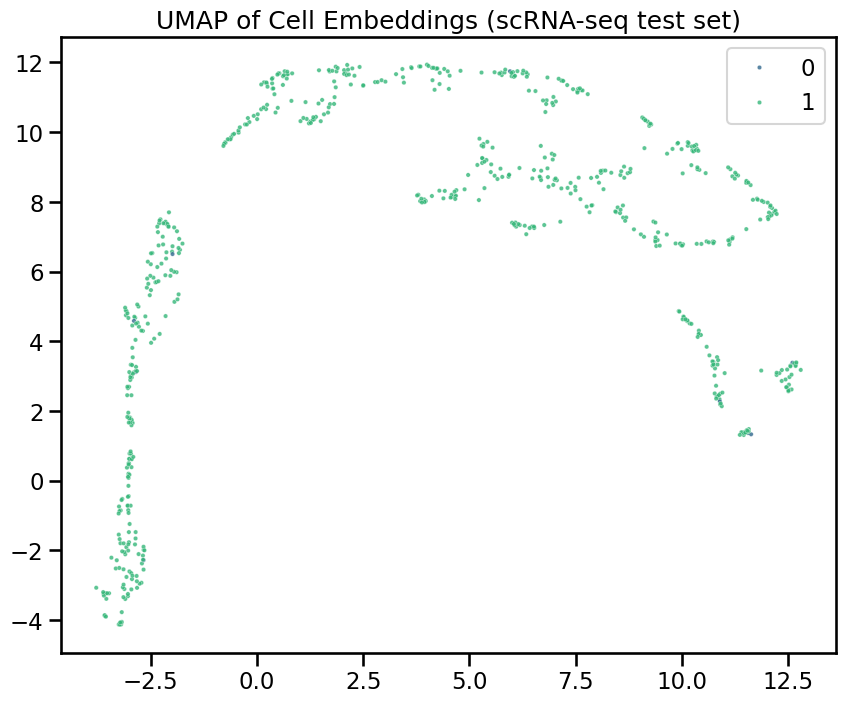

In [14]:
try:
    # Clear previous plots
    plt.clf()
except:
    pass
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding_2d[:, 0], y=embedding_2d[:, 1], hue=cell_labels, palette="viridis", legend="full", s=10, alpha=0.8)
plt.title("UMAP of Cell Embeddings (scRNA-seq test set)")
plt.show()